# 5.3 Model Tuning
## Grid Search · Random Search · Bayesian Optimization · Strategies

---

## What is Model Tuning?

When you train a machine learning model, there are two types of settings:

| Type | What it is | Example | Who sets it? |
|------|-----------|---------|--------------|
| **Parameters** | Values the model learns from data automatically | tree split thresholds, weights | The algorithm |
| **Hyperparameters** | Settings YOU choose BEFORE training | number of trees, learning rate, max depth | You (the data scientist) |

> **Model Tuning = finding the best hyperparameters for your model.**

---

## Simple Analogy — Baking a Cake

```
You want to bake the perfect cake. You need to decide:
  - Oven temperature: 160°C, 180°C, or 200°C?
  - Baking time: 25 min, 30 min, or 35 min?
  - Sugar amount: 100g, 150g, or 200g?

You can't know the perfect combination in advance.
You have to TRY different combinations and see which tastes best.

That is exactly what hyperparameter tuning does for ML models.
```

---

## Why Does Tuning Matter?

```
Same model (Random Forest) — different hyperparameters:

  Bad hyperparameters  →  Test accuracy = 72%
  Good hyperparameters →  Test accuracy = 89%

Same algorithm. Same data. 17% better just from tuning!
```

---

## The 3 Main Approaches

| Method | How it works | Speed | Best for |
|--------|-------------|-------|---------|
| **Grid Search** | Try EVERY combination | Slowest | Small grids, when you must be exhaustive |
| **Random Search** | Try RANDOM combinations | Fast | Large grids, usually 90% as good |
| **Bayesian Optimization** | Smart: use past results to pick next best | Fastest | Expensive models, large search spaces |

---

## Topics in this notebook

1. **Grid Search** — what it is, how it works, code, pros/cons
2. **Random Search** — what it is, how it works, code, pros/cons
3. **Bayesian Optimization** — what it is, how it works, code, pros/cons
4. **Tuning Strategies** — which hyperparameters matter most, practical tips
5. **Visual comparison** — all 3 methods side by side


In [1]:
# Imports and shared dataset used across all sections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      RandomizedSearchCV, cross_val_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats import randint, uniform

# Shared dataset — customer churn (binary classification)
np.random.seed(42)
X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=6,
    n_redundant=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')
print('\nDataset ready for all tuning experiments.')


Training samples : 800
Test samples     : 200
Features         : 10

Dataset ready for all tuning experiments.


---
# 1. Grid Search

---

## What is Grid Search?

> **Definition:** Try EVERY possible combination of hyperparameters from a predefined grid.
> Use cross-validation to score each combination. Return the best one.

---

## Simple Analogy

```
You want to find the best pizza at a restaurant.
The menu has:

  Crust:    thin, thick               (2 options)
  Sauce:    tomato, white, pesto      (3 options)
  Topping:  cheese, pepperoni, veggie (3 options)

Grid Search = order EVERY combination:
  thin + tomato + cheese
  thin + tomato + pepperoni
  thin + tomato + veggie
  thin + white  + cheese
  ... (2 × 3 × 3 = 18 combinations total)

Try all 18. Pick the best one.
```

---

## How it Works — Step by Step

```
STEP 1 — Define the grid:
  param_grid = {
    'n_estimators': [50, 100, 200],      # 3 choices
    'max_depth':    [3, 5, None],        # 3 choices
    'min_samples_leaf': [1, 5, 10]       # 3 choices
  }
  Total combinations = 3 × 3 × 3 = 27

STEP 2 — For EACH of the 27 combinations:
  Train model on fold 1,2,3,4  →  test on fold 5
  Train model on fold 1,2,3,5  →  test on fold 4
  Train model on fold 1,2,4,5  →  test on fold 3
  ... (5-fold cross validation)
  Average score = CV score for this combination

STEP 3 — Pick the combination with the highest CV score.

Total model fits = 27 combinations × 5 folds = 135 fits!
```

---

## Grid Search Visualised

```
n_estimators →   50      100     200
                ┌─────┬───────┬───────┐
max_depth=3     │ fit │  fit  │  fit  │  ← try all 3 n_estimators at depth=3
                ├─────┼───────┼───────┤
max_depth=5     │ fit │  fit  │  fit  │  ← try all 3 n_estimators at depth=5
                ├─────┼───────┼───────┤
max_depth=None  │ fit │  fit  │  fit  │  ← try all 3 n_estimators at depth=None
                └─────┴───────┴───────┘
Each cell = one combination. Every cell is evaluated. (This is just 2 params shown.)
```

---

## Advantages

| # | Advantage |
|---|-----------|
| 1 | **Guaranteed to find the best combination** within the grid |
| 2 | **Simple to understand** — you see exactly what was searched |
| 3 | **Reproducible** — same grid always gives same result |
| 4 | **Parallelisable** — `n_jobs=-1` runs all combinations in parallel |

## Disadvantages

| # | Disadvantage |
|---|--------------|
| 1 | **Combinatorial explosion** — 5 params × 5 values = 5⁵ = 3125 fits! |
| 2 | **Wastes time on bad regions** — tries everything even if most is useless |
| 3 | **Only searches discrete values** — can't explore between grid points |
| 4 | **Doesn't learn from results** — tries bad combos even after seeing they fail |

---

## When to use Grid Search?

```
USE when:
  - You have a small grid (< 100 combinations)
  - You know the rough range of good values
  - Training is fast (seconds per fit)

AVOID when:
  - More than 3-4 hyperparameters
  - Wide value ranges (0.001 to 10)
  - Training is slow (minutes per fit)
```


Grid size: [3, 3, 3] -> 27 combinations
With 5-fold CV: 27 x 5 = 135 model fits

GRID SEARCH RESULTS
Time taken      : 4.7 seconds
Best CV ROC-AUC : 0.9622
Best params     : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Test ROC-AUC    : 0.9596
Test Accuracy   : 0.8950


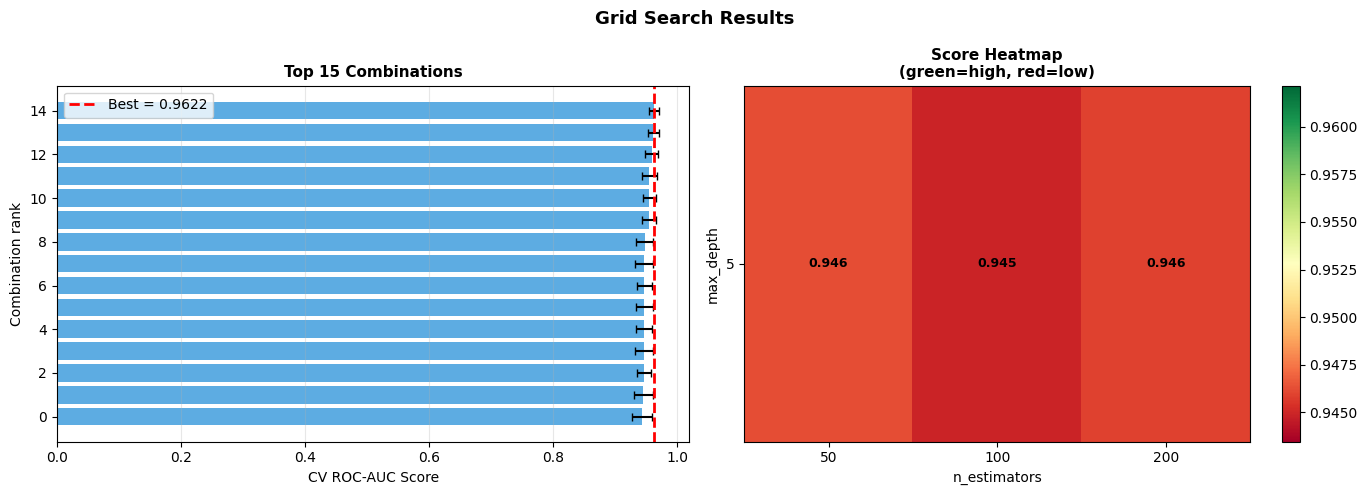


Best combination found: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}


In [2]:
# ============================================================
# GRID SEARCH — full example with visualisation
# ============================================================

# STEP 1: Define the grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, None],
    'min_samples_leaf': [1, 5, 10]
}

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)

print(f'Grid size: {[len(v) for v in param_grid.values()]} -> {total_combos} combinations')
print(f'With 5-fold CV: {total_combos} x 5 = {total_combos*5} model fits')
print()

# STEP 2: Run Grid Search
t0 = time.time()
gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='roc_auc',   # metric to optimise
    n_jobs=-1,           # use all CPU cores
    verbose=0,
    return_train_score=True
)
gs.fit(X_train, y_train)
t_grid = time.time() - t0

# STEP 3: Results
print('GRID SEARCH RESULTS')
print('='*50)
print(f'Time taken      : {t_grid:.1f} seconds')
print(f'Best CV ROC-AUC : {gs.best_score_:.4f}')
print(f'Best params     : {gs.best_params_}')
print(f'Test ROC-AUC    : {roc_auc_score(y_test, gs.best_estimator_.predict_proba(X_test)[:,1]):.4f}')
print(f'Test Accuracy   : {accuracy_score(y_test, gs.best_estimator_.predict(X_test)):.4f}')

# STEP 4: Visualise top 15 combinations
results_df = pd.DataFrame(gs.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Grid Search Results', fontsize=13, fontweight='bold')

# Top 15 scores
axes[0].barh(range(len(results_df)),
             results_df['mean_test_score'].values[::-1],
             xerr=results_df['std_test_score'].values[::-1],
             color='#3498db', alpha=0.8, capsize=3)
axes[0].axvline(gs.best_score_, color='red', lw=2, linestyle='--',
                label=f'Best = {gs.best_score_:.4f}')
axes[0].set_xlabel('CV ROC-AUC Score'); axes[0].set_ylabel('Combination rank')
axes[0].set_title('Top 15 Combinations', fontsize=11, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='x')

# Heatmap: n_estimators vs max_depth (averaging over min_samples_leaf)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators',
    aggfunc='mean'
)
im = axes[1].imshow(pivot.values, cmap='RdYlGn', aspect='auto',
                    vmin=results_df['mean_test_score'].min(),
                    vmax=results_df['mean_test_score'].max())
axes[1].set_xticks(range(len(pivot.columns)))
axes[1].set_xticklabels(pivot.columns, fontsize=10)
axes[1].set_yticks(range(len(pivot.index)))
axes[1].set_yticklabels(pivot.index, fontsize=10)
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('max_depth')
axes[1].set_title('Score Heatmap\n(green=high, red=low)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=axes[1])
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i,j]
        if not np.isnan(val):
            axes[1].text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()

print(f'\nBest combination found: {gs.best_params_}')


---
# 2. Random Search

---

## What is Random Search?

> **Definition:** Instead of trying EVERY combination, randomly sample N combinations
> from the hyperparameter space. Much faster, and surprisingly almost as good.

---

## Simple Analogy

```
Same pizza restaurant, same menu.
But now instead of ordering all 18 combinations:

  Random Search = randomly pick 8 combinations and try only those:
    thin + pesto + cheese          (random pick)
    thick + tomato + pepperoni     (random pick)
    thin + white + veggie          (random pick)
    ... (8 random picks)

Usually one of those 8 will be very good.
You saved 10 orders (18 - 8 = 10) but still found a great pizza!
```

**Key insight (from research):**
> With Random Search, 60 random trials cover 95% of the parameter space
> as well as a full grid search. (Bergstra & Bengio, 2012)

---

## Grid Search vs Random Search — The Key Difference

```
Grid Search samples a grid:             Random Search samples randomly:

  param1 →  1   2   3   4   5            param1 →  1   2   3   4   5
            ┌─┬─┬─┬─┬─┐                           ·   ·   X   ·   X
param2      │X│X│X│X│X│                  param2    X   ·   ·   X   ·
            ├─┼─┼─┼─┼─┤                           ·   X   ·   ·   X
            │X│X│X│X│X│                            X   ·   X   ·   ·
            └─┴─┴─┴─┴─┘                            ·   X   ·   X   ·

  Tries all 25 combinations             Tries 8 random combinations
  (5×5 = 25 fits)                       Much faster! Still covers space well.

  PROBLEM: If param2 doesn't matter,    BENEFIT: Explores full range of param1
  you wasted 5× more time than needed.  rather than 5 fixed values only.
```

---

## Advantages

| # | Advantage |
|---|-----------|
| 1 | **Much faster** — only N fits instead of all combinations |
| 2 | **Covers continuous ranges** — can sample any value in a range, not just fixed ones |
| 3 | **Scales well** — adding a new hyperparameter doesn't multiply fits |
| 4 | **Usually 90% as good** as grid search in much less time |

## Disadvantages

| # | Disadvantage |
|---|--------------|
| 1 | **Not guaranteed** to find the absolute best combination |
| 2 | **Doesn't learn** from previous results — each trial is still random |
| 3 | **Needs enough trials** — too few and you might miss the good region |
| 4 | **Results vary** — different random seeds give different results |

---

## When to use Random Search?

```
USE when:
  - More than 3 hyperparameters to tune
  - Wide continuous ranges (learning_rate: 0.001 to 0.3)
  - Training takes moderate time
  - You want a quick good-enough result

AVOID when:
  - Grid is small (< 50 combinations) — just use Grid Search
  - You absolutely must find the global best (rare in practice)
```


Random Search: trying 40 random combinations
Grid Search equivalent would be: 900 = 900 combinations
Speed-up: ~22x faster

RANDOM SEARCH RESULTS
Time taken      : 8.6 seconds
Best CV ROC-AUC : 0.9629
Best params     : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 363}
Test ROC-AUC    : 0.9586
Test Accuracy   : 0.8900


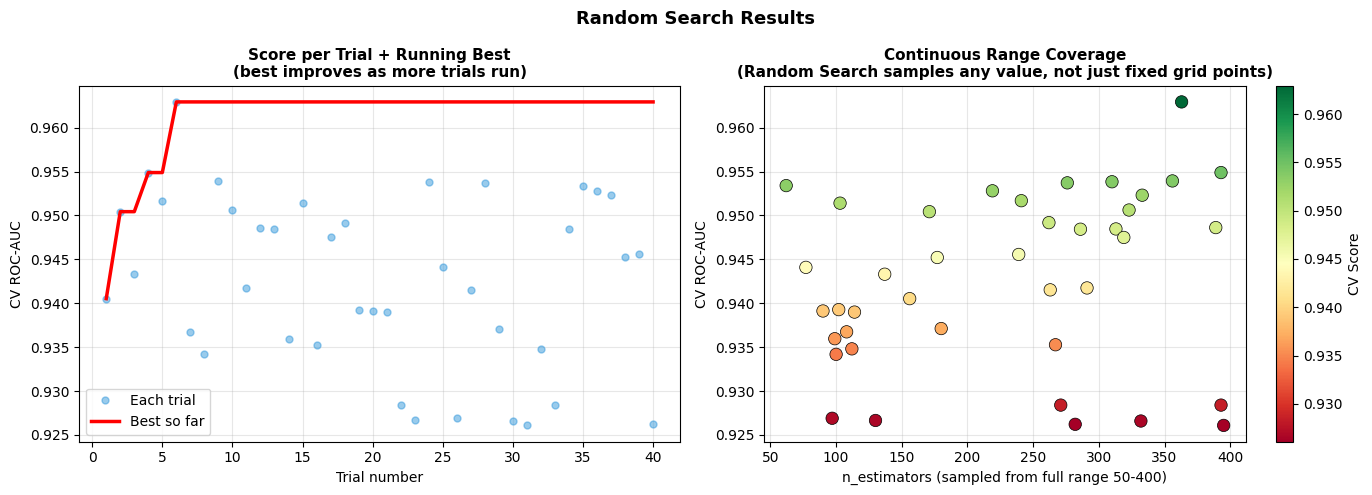

In [3]:
# ============================================================
# RANDOM SEARCH — full example with visualisation
# ============================================================

from scipy.stats import randint, uniform

# STEP 1: Define distributions (not just fixed values!)
param_dist = {
    'n_estimators':     randint(50, 400),       # any integer 50-399
    'max_depth':        [3, 5, 7, 10, None],    # discrete choices
    'min_samples_leaf': randint(1, 20),          # any integer 1-19
    'max_features':     ['sqrt', 'log2', None], # discrete choices
}

n_iter = 40   # try only 40 random combinations

print(f'Random Search: trying {n_iter} random combinations')
print(f'Grid Search equivalent would be: {3*5*20*3} = 900 combinations')
print(f'Speed-up: ~{900//n_iter}x faster')
print()

# STEP 2: Run Random Search
t0 = time.time()
rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=n_iter,       # number of random combinations to try
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0,
    return_train_score=True
)
rs.fit(X_train, y_train)
t_rand = time.time() - t0

# STEP 3: Results
print('RANDOM SEARCH RESULTS')
print('='*50)
print(f'Time taken      : {t_rand:.1f} seconds')
print(f'Best CV ROC-AUC : {rs.best_score_:.4f}')
print(f'Best params     : {rs.best_params_}')
print(f'Test ROC-AUC    : {roc_auc_score(y_test, rs.best_estimator_.predict_proba(X_test)[:,1]):.4f}')
print(f'Test Accuracy   : {accuracy_score(y_test, rs.best_estimator_.predict(X_test)):.4f}')

# STEP 4: Visualise — score improving as more trials run
rs_results = pd.DataFrame(rs.cv_results_).sort_index()
cumulative_best = rs_results['mean_test_score'].cummax()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Search Results', fontsize=13, fontweight='bold')

# Cumulative best score
axes[0].plot(range(1, n_iter+1), rs_results['mean_test_score'],
             'o', color='#3498db', alpha=0.5, markersize=5, label='Each trial')
axes[0].plot(range(1, n_iter+1), cumulative_best,
             'r-', lw=2.5, label='Best so far')
axes[0].set_xlabel('Trial number'); axes[0].set_ylabel('CV ROC-AUC')
axes[0].set_title('Score per Trial + Running Best\n'                  '(best improves as more trials run)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# n_estimators sampled — shows full range coverage
sampled_n = [p['n_estimators'] for p in rs_results['params']]
sampled_scores = rs_results['mean_test_score'].values
sc = axes[1].scatter(sampled_n, sampled_scores,
                     c=sampled_scores, cmap='RdYlGn',
                     s=80, edgecolors='black', lw=0.5, zorder=3)
plt.colorbar(sc, ax=axes[1], label='CV Score')
axes[1].set_xlabel('n_estimators (sampled from full range 50-400)')
axes[1].set_ylabel('CV ROC-AUC')
axes[1].set_title('Continuous Range Coverage\n'                  '(Random Search samples any value, not just fixed grid points)',
                  fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


---
# 3. Bayesian Optimization

---

## What is Bayesian Optimization?

> **Definition:** Use the results of past trials to **intelligently decide** which
> hyperparameters to try next. Builds a model of "which regions are promising"
> and explores those first.

Both Grid Search and Random Search are "blind" — they don't learn from results.
Bayesian Optimization is "smart" — it learns from each trial and gets better.

---

## Simple Analogy

```
You are searching for buried treasure on a beach.

Grid Search:  dig holes in a perfect grid pattern across the whole beach.
Random Search: dig random holes across the beach.
Bayesian:     dig one hole. Not treasure? OK. Dig nearby but slightly different.
              Find some gold? Dig MORE holes in that region!
              Use each result to guide WHERE to dig next.

Bayesian = learns from every result to focus on the most promising areas.
```

---

## How Bayesian Optimization Works

```
STEP 1: Try a few random combinations (exploration phase)
  Trial 1: n_estimators=100, lr=0.1  →  score=0.82
  Trial 2: n_estimators=200, lr=0.3  →  score=0.79
  Trial 3: n_estimators=50,  lr=0.05 →  score=0.85

STEP 2: Build a "surrogate model" (Gaussian Process)
  This model estimates: "given these params, what score do we expect?"
  It also knows its own uncertainty — where it hasn't explored yet.

STEP 3: Use "acquisition function" to pick the next best point
  Balance between:
    EXPLOITATION — try near the best result so far (score=0.85 at lr=0.05)
    EXPLORATION  — try regions not yet visited (high uncertainty)

STEP 4: Try that point, update the surrogate model
  Trial 4: n_estimators=80, lr=0.04  →  score=0.87  <- new best!

STEP 5: Repeat. Each trial makes smarter choices.
```

---

## Visual Intuition

```
Score landscape (we don't know this in advance):

  lr
  0.3  ░░▒▒▓▓██████▓▓▒▒░░
  0.2  ░░▒▒▒▓▓█████▓▓▒▒░░
  0.1  ░░░▒▒▒▓▓██▓▓▒▒░░░
  0.05 ░░░░▒▒▒▓▓▓▒▒░░░░░
       50  100  200  300   n_estimators
       █ = high score region

Grid/Random: sample points blindly, may miss the peak.
Bayesian:    after a few points, focuses trials on the █ region.
```

---

## sklearn options for Bayesian-style search

| Tool | Package | Notes |
|------|---------|-------|
| `HalvingRandomSearchCV` | sklearn (built-in) | Not pure Bayesian but adaptive — starts many, keeps best |
| `BayesSearchCV` | `scikit-optimize` | True Bayesian with Gaussian Process |
| `optuna.create_study` | `optuna` | Best for complex models, very popular |
| `hyperopt` | `hyperopt` | Tree-structured Parzen Estimator (TPE) |

---

## Advantages

| # | Advantage |
|---|-----------|
| 1 | **Fewest trials needed** — smart choices → finds optimum fast |
| 2 | **Best for expensive models** — every trial counts when training takes hours |
| 3 | **Handles complex landscapes** — learns non-obvious interactions between params |
| 4 | **Explores AND exploits** — balances searching new areas vs refining known good ones |

## Disadvantages

| # | Disadvantage |
|---|--------------|
| 1 | **More complex to set up** — needs extra libraries (optuna, scikit-optimize) |
| 2 | **Sequential by default** — each trial depends on previous, harder to parallelise |
| 3 | **Overkill for small grids** — Grid Search is simpler and fine for < 100 combos |
| 4 | **Surrogate model overhead** — fitting the Gaussian Process adds cost per trial |

---

## When to use Bayesian Optimization?

```
USE when:
  - Each training run takes minutes or hours (deep learning, large XGBoost)
  - You have many hyperparameters (5+)
  - You want the absolute best result with the fewest trials
  - You're running in a Kaggle competition

USE simpler methods when:
  - Training is fast (seconds)
  - Grid is small
  - Quick experiment, not final tuning
```


METHOD A: HalvingRandomSearchCV (sklearn built-in adaptive search)
How it works:
  Round 1: Start with 100 candidates, train each on 10% of data
  Round 2: Keep top 33, train each on 30% of data
  Round 3: Keep top 11, train each on 100% of data
  Final:   Best of 11 candidates -> much less compute than Grid Search

Time taken      : 8.7 seconds
Best CV ROC-AUC : 0.9373
Best params     : {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 355}
Test ROC-AUC    : 0.9544


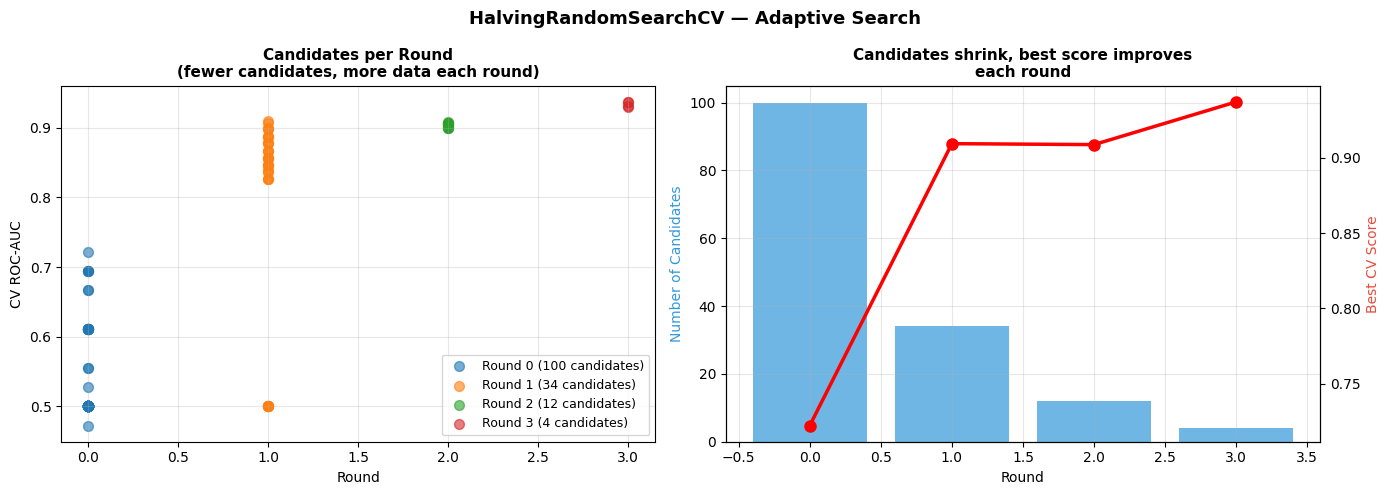


METHOD B: Optuna (true Bayesian — run if installed: pip install optuna)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 400),
        'max_depth':        trial.suggest_int('max_depth', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt','log2']),
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    score = cross_val_score(model, X_train, y_train,
                            cv=3, scoring='roc_auc').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best score :", study.best_value)
print("Best params:", study.best_params)



In [5]:
# ============================================================
# BAYESIAN-STYLE SEARCH — HalvingRandomSearchCV (sklearn built-in)
# + optuna example (if installed)
# ============================================================

from sklearn.experimental import enable_halving_search_cv  # must import before HalvingRandomSearchCV
from sklearn.model_selection import HalvingRandomSearchCV
from scipy.stats import randint

print('METHOD A: HalvingRandomSearchCV (sklearn built-in adaptive search)')
print('='*60)
print('''How it works:
  Round 1: Start with 100 candidates, train each on 10% of data
  Round 2: Keep top 33, train each on 30% of data
  Round 3: Keep top 11, train each on 100% of data
  Final:   Best of 11 candidates -> much less compute than Grid Search
''')

param_dist = {
    'n_estimators':     randint(50, 400),
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_leaf': randint(1, 20),
    'max_features':     ['sqrt', 'log2'],
}

t0 = time.time()
halving = HalvingRandomSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    factor=3,            # keep 1/3 of candidates each round
    n_candidates=100,    # start with 100 random candidates
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
halving.fit(X_train, y_train)
t_halv = time.time() - t0

print(f'Time taken      : {t_halv:.1f} seconds')
print(f'Best CV ROC-AUC : {halving.best_score_:.4f}')
print(f'Best params     : {halving.best_params_}')
print(f'Test ROC-AUC    : {roc_auc_score(y_test, halving.best_estimator_.predict_proba(X_test)[:,1]):.4f}')

# Visualise the halving rounds
halv_df = pd.DataFrame(halving.cv_results_)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HalvingRandomSearchCV — Adaptive Search', fontsize=13, fontweight='bold')

for rnd in sorted(halv_df['iter'].unique()):
    rnd_df = halv_df[halv_df['iter']==rnd]
    axes[0].scatter([rnd]*len(rnd_df), rnd_df['mean_test_score'],
                    alpha=0.6, s=50, label=f'Round {rnd} ({len(rnd_df)} candidates)')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('CV ROC-AUC')
axes[0].set_title('Candidates per Round\n(fewer candidates, more data each round)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

round_counts = halv_df.groupby('iter').size()
round_best   = halv_df.groupby('iter')['mean_test_score'].max()
ax2 = axes[1]
color1 = '#3498db'; color2 = '#e74c3c'
bars = ax2.bar(round_counts.index, round_counts.values, color=color1, alpha=0.7, label='# candidates')
ax2.set_ylabel('Number of Candidates', color=color1)
ax3 = ax2.twinx()
ax3.plot(round_best.index, round_best.values, 'r-o', lw=2.5,
         markersize=8, label='Best score this round')
ax3.set_ylabel('Best CV Score', color=color2)
ax2.set_xlabel('Round')
ax2.set_title('Candidates shrink, best score improves\neach round',
              fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Optuna example (shown as code — run if optuna is installed)
print()
print('METHOD B: Optuna (true Bayesian — run if installed: pip install optuna)')
print('='*60)
print('''
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 400),
        'max_depth':        trial.suggest_int('max_depth', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt','log2']),
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    score = cross_val_score(model, X_train, y_train,
                            cv=3, scoring='roc_auc').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best score :", study.best_value)
print("Best params:", study.best_params)
''')


---
# 4. Hyperparameter Tuning Strategies

---

## Which Hyperparameters Matter Most?

Not all hyperparameters are equally important. Tune these first:

### Random Forest — Priority Order

```
HIGH IMPACT (tune first):
  n_estimators      → more trees = better, but diminishing returns after ~200
  max_features      → 'sqrt' for classification, n/3 for regression
  max_depth         → None is fine (RF self-regulates), but try 5-15 if overfitting
  min_samples_leaf  → increase (2-10) on noisy data to reduce overfitting

LOW IMPACT (tune last or leave default):
  bootstrap         → almost always True
  criterion         → 'gini' vs 'entropy' rarely matters much
  min_samples_split → usually covered by min_samples_leaf
```

### Gradient Boosting / XGBoost — Priority Order

```
HIGH IMPACT (tune first):
  n_estimators      → 100-1000, use early stopping to find optimal
  learning_rate     → 0.01-0.3, lower rate + more trees = better
  max_depth         → 3-8, keep shallow to prevent overfit
  subsample         → 0.6-0.9, like bagging for rows
  colsample_bytree  → 0.6-0.9, like bagging for columns

MEDIUM IMPACT:
  min_child_weight  → higher = more conservative
  gamma             → minimum loss reduction for split
  reg_alpha (L1)    → feature sparsity
  reg_lambda (L2)   → weight shrinkage

GOLDEN RULE for GBM:
  learning_rate and n_estimators trade off each other.
  Lower learning_rate -> need more n_estimators -> slower but better.
  Use early stopping to auto-find the right n_estimators.
```

---

## Practical Tuning Strategy — Step by Step

```
STEP 1: Start with defaults
  Train once with defaults. Note baseline accuracy.
  No point tuning if defaults already work well.

STEP 2: Quick Random Search (wide range)
  Try 20-50 random combinations across wide ranges.
  Goal: find WHICH region of the space is good.

STEP 3: Focused Grid Search (narrow range)
  Take the best params from step 2.
  Search a narrow grid around those values.
  Goal: fine-tune within the good region.

STEP 4: Validate on test set
  Use the final best params once on the held-out test set.
  Never tune using the test set (data leakage!).

STEP 5: Check if tuning actually helped
  If improvement < 1%, the gain might not be worth the complexity.
  Simple models with good features often beat tuned complex models.
```

---

## Common Mistakes in Tuning

| Mistake | What goes wrong | Fix |
|---------|----------------|-----|
| Tuning on test set | You overfit to test set, real-world perf is worse | Always use CV |
| Too narrow grid | Miss the optimal region entirely | Start wide, then narrow |
| Tuning before feature engineering | Bad features can't be fixed by tuning | Engineer features first |
| Over-tuning small datasets | Tiny improvement in CV = noise, not signal | Use larger CV (10-fold) |
| Ignoring training time | Best params take 10h to train — impractical | Set time budget first |

---

## Learning Rate vs n_estimators Trade-off (GBM)

```
High learning rate + few trees:
  lr=0.3, n=100  →  trains fast, lower accuracy, easy to overfit

Low learning rate + many trees:
  lr=0.01, n=1000 →  trains slow, higher accuracy, better generalisation

RULE OF THUMB:
  Start with lr=0.1, n=200.
  If accuracy is not enough: halve lr, double n.
  Use early stopping to auto-find best n.
```


PART A: Learning Rate vs n_estimators (Gradient Boosting)


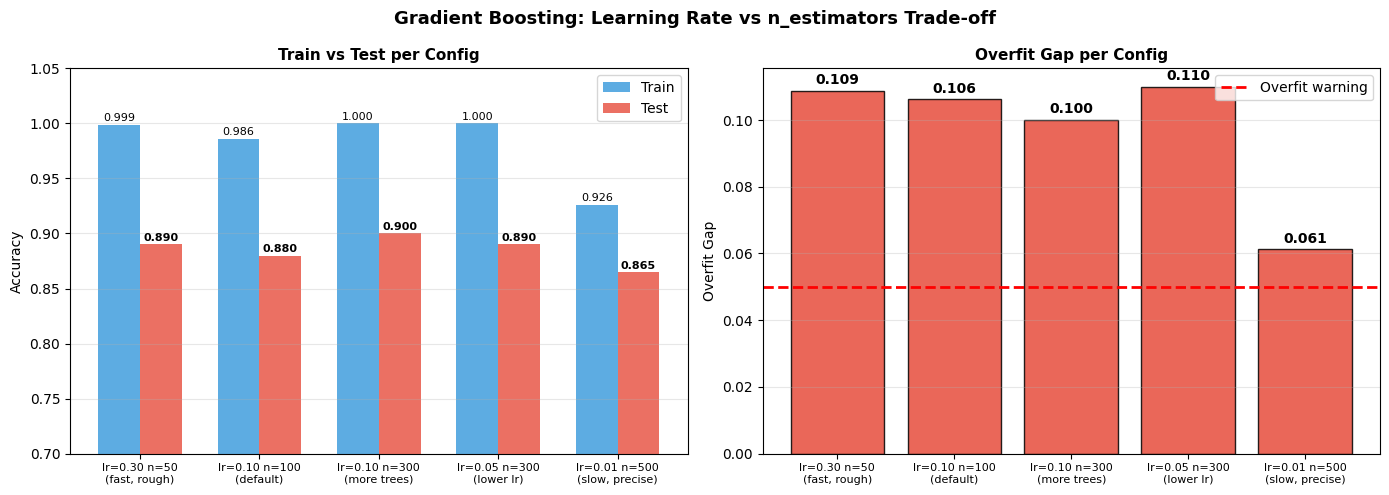


  Config                      Train    Test     Gap
--------------------------------------------------
  lr=0.30 n=50 (fast, rough)   0.999   0.890   0.109
  lr=0.10 n=100 (default)     0.986   0.880   0.106
  lr=0.10 n=300 (more trees)   1.000   0.900   0.100
  lr=0.05 n=300 (lower lr)    1.000   0.890   0.110
  lr=0.01 n=500 (slow, precise)   0.926   0.865   0.061

PART B: Grid Search vs Random Search vs Halving — Head to Head


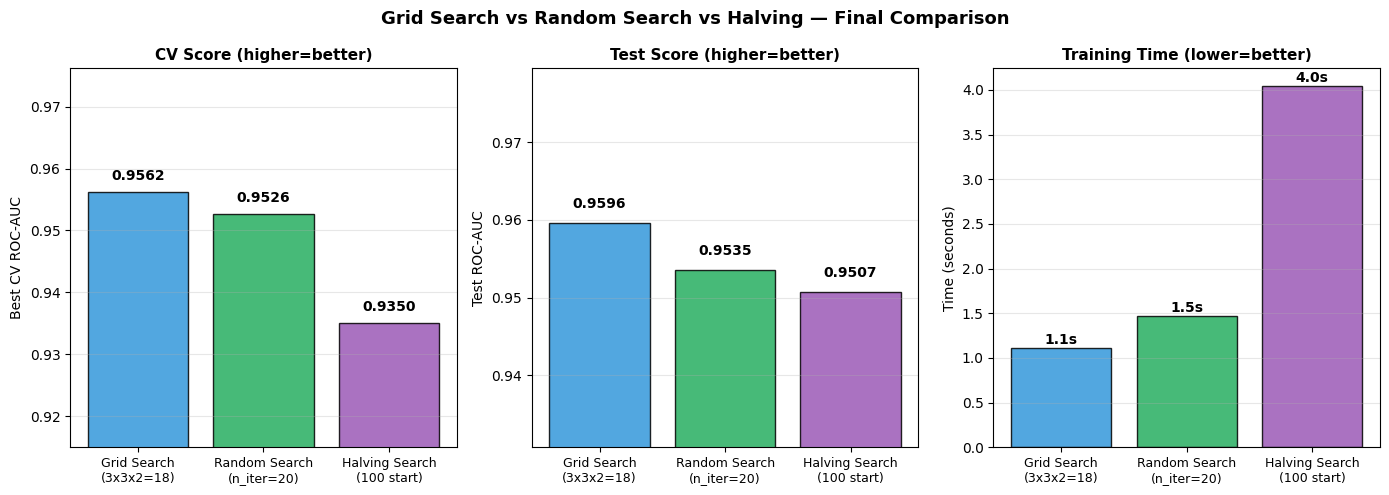


  Method                       CV AUC   Test AUC     Time
------------------------------------------------------------
  Grid Search (3x3x2=18)       0.9562     0.9596     1.1s
  Random Search (n_iter=20)    0.9526     0.9535     1.5s
  Halving Search (100 start)    0.9350     0.9507     4.0s


In [6]:
# ============================================================
# TUNING STRATEGIES — learning rate vs n_estimators + full comparison
# ============================================================

# --- PART A: Learning rate vs n_estimators trade-off ---
print('PART A: Learning Rate vs n_estimators (Gradient Boosting)')
print('='*60)

configs = [
    {'lr': 0.30, 'n': 50,  'label': 'lr=0.30 n=50\n(fast, rough)'},
    {'lr': 0.10, 'n': 100, 'label': 'lr=0.10 n=100\n(default)'},
    {'lr': 0.10, 'n': 300, 'label': 'lr=0.10 n=300\n(more trees)'},
    {'lr': 0.05, 'n': 300, 'label': 'lr=0.05 n=300\n(lower lr)'},
    {'lr': 0.01, 'n': 500, 'label': 'lr=0.01 n=500\n(slow, precise)'},
]

train_scores, test_scores = [], []
for cfg in configs:
    gb = GradientBoostingClassifier(
        learning_rate=cfg['lr'], n_estimators=cfg['n'],
        max_depth=3, random_state=42)
    gb.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, gb.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  gb.predict(X_test)))

labels = [c['label'] for c in configs]
x = np.arange(len(labels)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gradient Boosting: Learning Rate vs n_estimators Trade-off',
             fontsize=13, fontweight='bold')

axes[0].bar(x-w/2, train_scores, w, label='Train', color='#3498db', alpha=0.8)
axes[0].bar(x+w/2, test_scores,  w, label='Test',  color='#e74c3c', alpha=0.8)
for xi,(tr,te) in enumerate(zip(train_scores,test_scores)):
    axes[0].text(xi-w/2, tr+0.003, f'{tr:.3f}', ha='center', fontsize=8)
    axes[0].text(xi+w/2, te+0.003, f'{te:.3f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylim(0.7, 1.05); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test per Config', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3, axis='y')

gaps = [tr-te for tr,te in zip(train_scores,test_scores)]
axes[1].bar(labels, gaps,
            color=['#e74c3c' if g>0.05 else '#27ae60' for g in gaps],
            alpha=0.85, edgecolor='black')
for xi,g in enumerate(gaps):
    axes[1].text(xi, g+0.002, f'{g:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(0.05, color='red', lw=2, linestyle='--', label='Overfit warning')
axes[1].set_ylabel('Overfit Gap'); axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_title('Overfit Gap per Config', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print()
print(f'  {"Config":<25} {"Train":>7} {"Test":>7} {"Gap":>7}')
print('-'*50)
for cfg, tr, te in zip(configs, train_scores, test_scores):
    print(f'  {cfg["label"].replace(chr(10)," "):<25} {tr:>7.3f} {te:>7.3f} {tr-te:>7.3f}')

# --- PART B: All 3 search methods compared ---
print()
print('PART B: Grid Search vs Random Search vs Halving — Head to Head')
print('='*60)

# Re-run all 3 for fair comparison
param_grid_small = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, None],
    'min_samples_leaf': [1, 5]
}
param_dist_cmp = {
    'n_estimators':     randint(50, 300),
    'max_depth':        [3, 5, 7, None],
    'min_samples_leaf': randint(1, 15),
}

methods = {}
for name, searcher in [
    ('Grid Search\n(3x3x2=18)', GridSearchCV(
        RandomForestClassifier(random_state=42), param_grid_small,
        cv=3, scoring='roc_auc', n_jobs=-1)),
    ('Random Search\n(n_iter=20)', RandomizedSearchCV(
        RandomForestClassifier(random_state=42), param_dist_cmp,
        n_iter=20, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)),
    ('Halving Search\n(100 start)', HalvingRandomSearchCV(
        RandomForestClassifier(random_state=42), param_dist_cmp,
        n_candidates=60, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)),
]:
    t0 = time.time()
    searcher.fit(X_train, y_train)
    elapsed = time.time() - t0
    test_auc = roc_auc_score(y_test, searcher.best_estimator_.predict_proba(X_test)[:,1])
    methods[name] = {'cv': searcher.best_score_, 'test': test_auc, 'time': elapsed}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Grid Search vs Random Search vs Halving — Final Comparison',
             fontsize=13, fontweight='bold')

names  = list(methods.keys())
cv_sc  = [v['cv']   for v in methods.values()]
tst_sc = [v['test'] for v in methods.values()]
times  = [v['time'] for v in methods.values()]
colors = ['#3498db','#27ae60','#9b59b6']

axes[0].bar(names, cv_sc, color=colors, alpha=0.85, edgecolor='black')
for xi,v in enumerate(cv_sc):
    axes[0].text(xi, v+0.002, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Best CV ROC-AUC'); axes[0].set_ylim(min(cv_sc)-0.02, max(cv_sc)+0.02)
axes[0].set_title('CV Score (higher=better)', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(names, fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(names, tst_sc, color=colors, alpha=0.85, edgecolor='black')
for xi,v in enumerate(tst_sc):
    axes[1].text(xi, v+0.002, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Test ROC-AUC'); axes[1].set_ylim(min(tst_sc)-0.02, max(tst_sc)+0.02)
axes[1].set_title('Test Score (higher=better)', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(names, fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(names, times, color=colors, alpha=0.85, edgecolor='black')
for xi,v in enumerate(times):
    axes[2].text(xi, v+0.05, f'{v:.1f}s', ha='center', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Time (seconds)'); axes[2].set_title('Training Time (lower=better)',
                   fontsize=11, fontweight='bold')
axes[2].set_xticklabels(names, fontsize=9); axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print(f'\n  {"Method":<25} {"CV AUC":>9} {"Test AUC":>10} {"Time":>8}')
print('-'*60)
for n, v in methods.items():
    print(f'  {n.replace(chr(10)," "):<25} {v["cv"]:>9.4f} {v["test"]:>10.4f} {v["time"]:>7.1f}s')


---
# Master Cheat Sheet — Model Tuning

---

## When to Use Which Method?

| Situation | Best Method |
|-----------|------------|
| Small grid (< 50 combos), fast training | **Grid Search** |
| Large grid, wide ranges, moderate training | **Random Search** |
| Slow training (mins/hours), need best result | **Bayesian (Optuna)** |
| Want sklearn only, no extra installs | **HalvingRandomSearchCV** |
| Quick first experiment | **Random Search (n_iter=20)** |

---

## sklearn Quick Reference

```python
# Grid Search
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
gs.fit(X_train, y_train)
gs.best_params_      # best hyperparameters
gs.best_score_       # best CV score
gs.best_estimator_   # the best trained model

# Random Search
from sklearn.model_selection import RandomizedSearchCV
rs = RandomizedSearchCV(model, param_dist, n_iter=50, cv=5,
                        scoring='roc_auc', n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)

# Halving (adaptive, sklearn built-in)
from sklearn.model_selection import HalvingRandomSearchCV
hs = HalvingRandomSearchCV(model, param_dist, factor=3, cv=3, n_jobs=-1)
hs.fit(X_train, y_train)

# Optuna (true Bayesian, pip install optuna)
import optuna
def objective(trial):
    params = {'n_estimators': trial.suggest_int('n_estimators', 50, 300)}
    return cross_val_score(RandomForestClassifier(**params),
                           X_train, y_train, cv=3).mean()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
study.best_params   # best found
```

---

## Key Hyperparameters for Common Models

```
Random Forest:
  n_estimators=100-500  max_features='sqrt'  max_depth=None  min_samples_leaf=1-5

Gradient Boosting / XGBoost:
  n_estimators=100-1000  learning_rate=0.01-0.1  max_depth=3-6
  subsample=0.8  colsample_bytree=0.8

Logistic Regression:
  C=0.001-100 (inverse regularisation)  penalty='l1'/'l2'

SVM:
  C=0.1-100  kernel='rbf'/'linear'  gamma='scale'/'auto'/0.001-1
```

---

## Common Scoring Metrics for GridSearchCV

| Task | Metric | Use when |
|------|--------|---------|
| Binary classification | `roc_auc` | Imbalanced data |
| Binary classification | `accuracy` | Balanced data |
| Binary classification | `f1` | False negatives are costly |
| Multi-class | `f1_macro` | Equal class importance |
| Regression | `neg_mean_squared_error` | Standard regression |
| Regression | `r2` | Variance explained |
